# IS aggregation: cycle from frequency thresholding

This notebook extends `05-is-aggregation.ipynb`.

We simulate acyclic subject DAGs on three nodes such that edge frequencies
above `tau` imply a directed 3-cycle (0→1→2→0). Each subject uses only two of
those edges, so every individual graph is a DAG.

Then we compare:

1. **Frequency-only pooled graph** — edges kept iff `frequency > tau` (no repair). This graph has a cycle.
2. **IS aggregation output** — same threshold, then lowest-frequency cycle-edge removal until acyclic. The result is a DAG.

In [1]:
import sys
from types import SimpleNamespace

sys.path.append("..")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from mdmp import aggregate_individual_structures, plot_dag


d:\dev\phd\sandbox\mdmr-python\mdmp\.venv-win\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic subjects (3 nodes, 6 subjects)

Each pattern is a length-2 path; together, majority vote closes the triangle.

| Pattern | Edges |
|---------|--------|
| A (×2) | 0→1, 1→2 |
| B (×2) | 1→2, 2→0 |
| C (×2) | 2→0, 0→1 |

With `S = 6`, each cycle edge appears in **4** subjects → frequency `4/6 ≈ 0.667 > 0.5`.


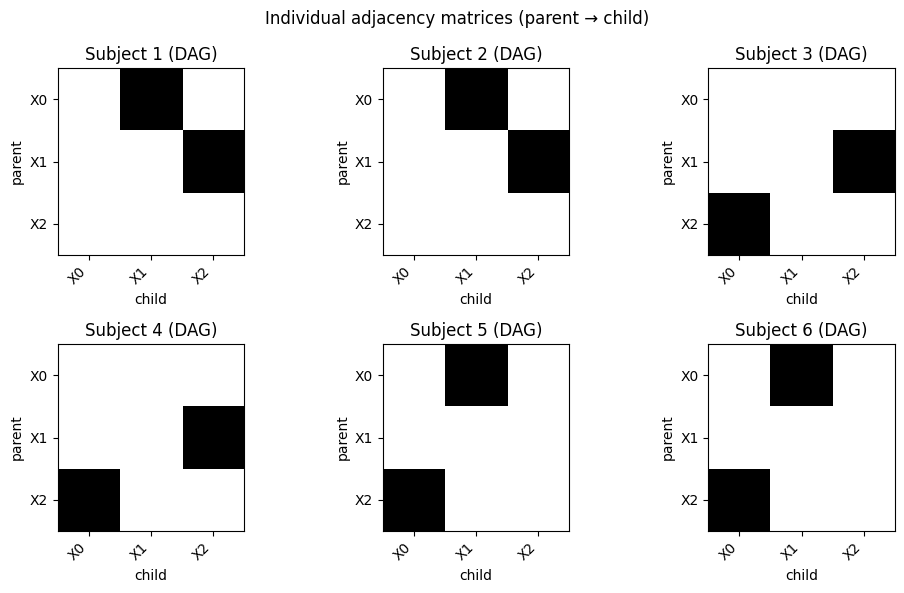

In [2]:
names = ["X0", "X1", "X2"]
n = 3


def dag():
    return np.zeros((n, n), dtype=int)


def path_forward():
    g = dag()
    g[0, 1] = g[1, 2] = 1
    return g


def path_shift1():
    g = dag()
    g[1, 2] = g[2, 0] = 1
    return g


def path_shift2():
    g = dag()
    g[2, 0] = g[0, 1] = 1
    return g


subject_dags = [
    path_forward(),
    path_forward(),
    path_shift1(),
    path_shift1(),
    path_shift2(),
    path_shift2(),
]
S = len(subject_dags)

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()
for ax, adj, s in zip(axes, subject_dags, range(1, S + 1)):
    ax.imshow(adj, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("child")
    ax.set_ylabel("parent")
    ax.set_title(f"Subject {s} (DAG)")
plt.suptitle("Individual adjacency matrices (parent → child)")
plt.tight_layout()
plt.show()


## Frequency-only vs IS (`tau = 0.5`)

- **Frequency-only**: `adj_freq = (edge_frequencies > tau)` — same rule as inside `aggregate_individual_structures` *before* cycle repair.
- **IS result**: `aggregate_individual_structures(...)` — includes acyclic repair; see `metadata["edges_removed_for_acyclicity"]`.


In [3]:
tau = 0.5
stack = np.stack(subject_dags, axis=0)
edge_counts = np.sum(stack, axis=0).astype(np.int64)
np.fill_diagonal(edge_counts, 0)
edge_frequencies = edge_counts.astype(float) / float(S)

adj_freq_only = (edge_frequencies > tau).astype(np.int8)
np.fill_diagonal(adj_freq_only, 0)

G_freq = nx.DiGraph()
G_freq.add_nodes_from(range(n))
for i in range(n):
    for j in range(n):
        if adj_freq_only[i, j]:
            G_freq.add_edge(i, j)

is_dag_freq = nx.is_directed_acyclic_graph(G_freq)
print("Frequency-only pooled graph is DAG?", is_dag_freq)
if not is_dag_freq:
    try:
        cyc = nx.find_cycle(G_freq, orientation="original")
        edges_cyc = []
        for item in cyc:
            if len(item) == 3:
                u, v, _ = item
                edges_cyc.append((int(u), int(v)))
            else:
                edges_cyc.append((int(item[0]), int(item[1])))
        print("Example directed cycle (edges):", edges_cyc)
    except nx.NetworkXNoCycle:
        pass

print("\nEdge frequencies (rows = parent, cols = child):")
print(pd.DataFrame(edge_frequencies, index=names, columns=names).round(3))

result = aggregate_individual_structures(subject_dags, tau=tau, node_names=names)
G_is = nx.DiGraph()
G_is.add_nodes_from(range(n))
adj_is = result.adj_mat.astype(int)
for i in range(n):
    for j in range(n):
        if adj_is[i, j]:
            G_is.add_edge(i, j)

is_dag_is = nx.is_directed_acyclic_graph(G_is)
print("\nIS output is DAG?", is_dag_is)
print("Edges removed for acyclicity:")
for e in result.metadata["edges_removed_for_acyclicity"]:
    print(e)


Frequency-only pooled graph is DAG? False
Example directed cycle (edges): [(0, 1), (1, 2), (2, 0)]

Edge frequencies (rows = parent, cols = child):
       X0     X1     X2
X0  0.000  0.667  0.000
X1  0.000  0.000  0.667
X2  0.667  0.000  0.000

IS output is DAG? True
Edges removed for acyclicity:
{'parent_idx': 0, 'child_idx': 1, 'parent_name': 'X0', 'child_name': 'X1', 'frequency': 0.6666666666666666}


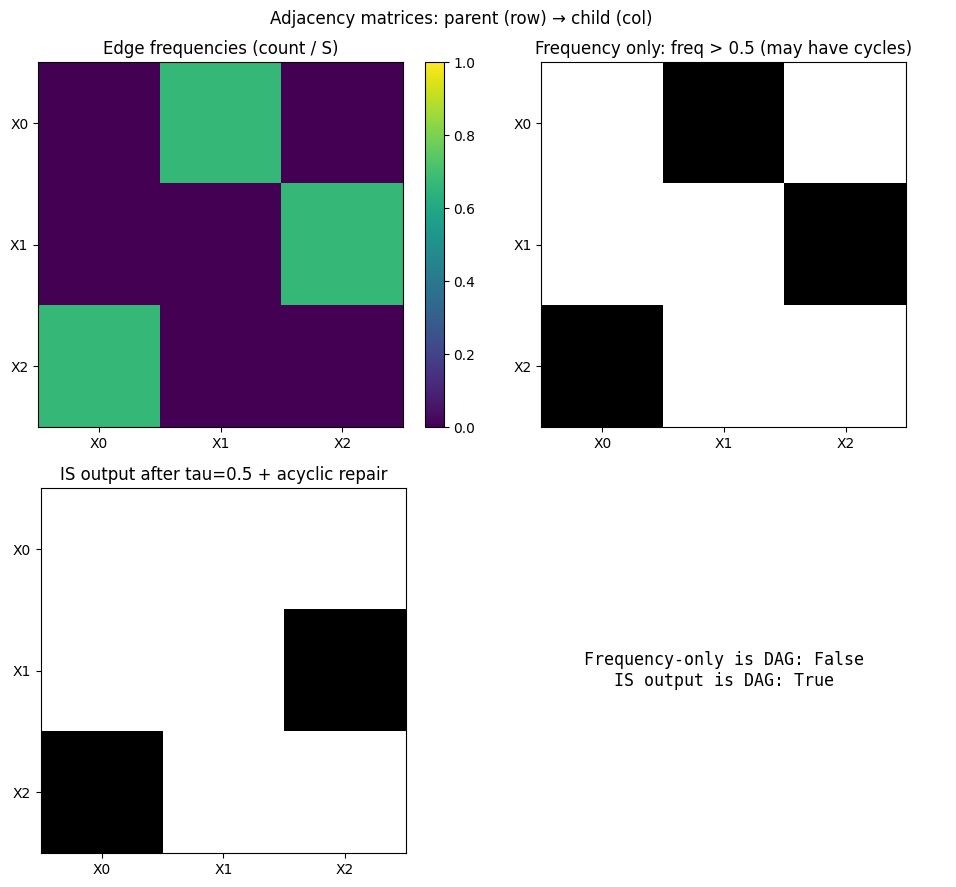

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))

im0 = axes[0, 0].imshow(edge_frequencies, cmap="viridis", vmin=0, vmax=1)
axes[0, 0].set_title("Edge frequencies (count / S)")
axes[0, 0].set_xticks(range(n))
axes[0, 0].set_yticks(range(n))
axes[0, 0].set_xticklabels(names)
axes[0, 0].set_yticklabels(names)
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(adj_freq_only, cmap="Greys", vmin=0, vmax=1)
axes[0, 1].set_title(f"Frequency only: freq > {tau} (may have cycles)")
axes[0, 1].set_xticks(range(n))
axes[0, 1].set_yticks(range(n))
axes[0, 1].set_xticklabels(names)
axes[0, 1].set_yticklabels(names)

im2 = axes[1, 0].imshow(adj_is, cmap="Greys", vmin=0, vmax=1)
axes[1, 0].set_title(f"IS output after tau={tau} + acyclic repair")
axes[1, 0].set_xticks(range(n))
axes[1, 0].set_yticks(range(n))
axes[1, 0].set_xticklabels(names)
axes[1, 0].set_yticklabels(names)

axes[1, 1].axis("off")
axes[1, 1].text(
    0.5,
    0.5,
    f"Frequency-only is DAG: {is_dag_freq}\nIS output is DAG: {is_dag_is}",
    ha="center",
    va="center",
    fontsize=12,
    family="monospace",
)
plt.suptitle("Adjacency matrices: parent (row) → child (col)")
plt.tight_layout()
plt.show()


## Graph layout (same `plot_dag` interface)

`plot_dag` uses `adj_mat` and `node_names` on the object; we wrap the frequency-only matrix in `SimpleNamespace` for the cyclic case.


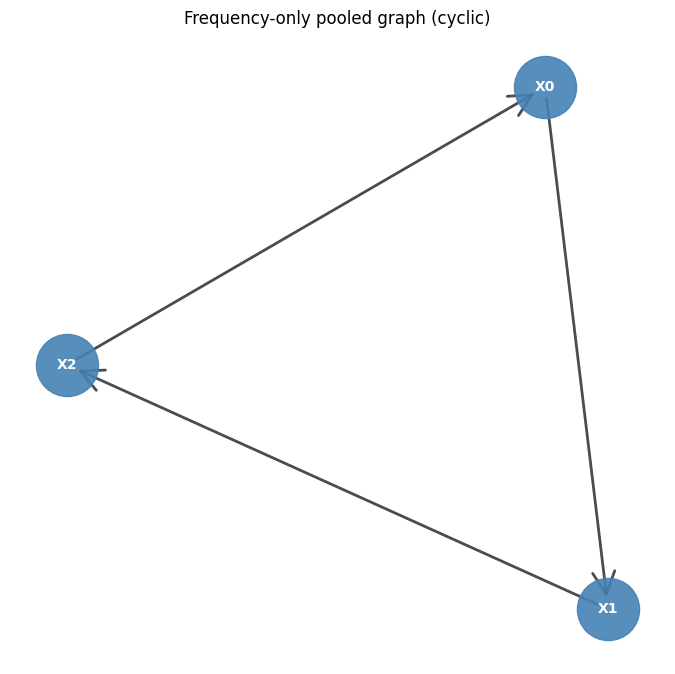

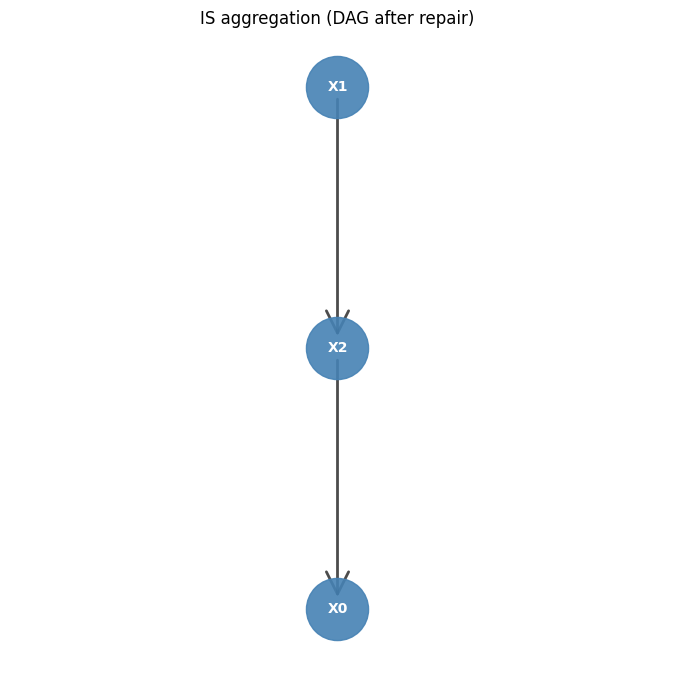

In [5]:
fig1 = plot_dag(
    SimpleNamespace(
        adj_mat=np.asarray(adj_freq_only, dtype=float), node_names=names
    ),
    plot_type="graph",
    layout_seed=0,
)
fig1.axes[0].set_title("Frequency-only pooled graph (cyclic)")
plt.show()

fig2 = plot_dag(result, plot_type="graph", layout_seed=0)
fig2.axes[0].set_title("IS aggregation (DAG after repair)")
plt.show()
